In [1]:
!pip install keras_facenet
import tensorflow as tf
from keras_facenet import FaceNet
import numpy as np
from tensorflow.keras import layers, models
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

In [2]:
def resize_to_160(img):
    """
    img: Tensor or numpy array of shape (256, 256, 3)
    returns: Tensor (160, 160, 3)
    """
    img = tf.image.resize(img, (160, 160), method='bilinear')
    img = img.numpy()
    return img

In [3]:
def get_embedding(img):
  """
  The embedder.embeddings function expects a list of numpy arrays.
  img is already a numpy array from resize_to_160, so we wrap it in a list.
  """
  img = resize_to_160(img)
  emb = embedder.embeddings([img])[0]
  #emb = np.expand_dims(emb, axis=0)
  return emb

In [4]:
def process_row(row):
    row["embedding"] = resize_to_160(row["image"])
    return row

In [5]:
def get_embeddings(images):
  images = np.array(images['image'])
  embeddings = embedder.embeddings(images)
  #emb = np.expand_dims(emb, axis=0)
  return {"embedding": embeddings}

In [6]:
from datasets import load_dataset

ds = load_dataset("tonyassi/celebrity-1000")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
ds['train'].shape

(18184, 2)

In [8]:
embedder = FaceNet()

In [9]:
keep = list(range(50))
ds_50 = ds['train'].filter(lambda x: x["label"] in keep)


In [10]:
ds_50 = ds_50.map(process_row)

In [11]:
ds_50 = ds_50.map(get_embeddings, batched=True)

Map:   0%|          | 0/895 [00:00<?, ? examples/s]

28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 365ms/step


In [12]:
split_ds = ds_50.train_test_split(test_size=0.3, stratify_by_column="label",shuffle=True)
train = split_ds['train']
split_ds = split_ds['test'].train_test_split(test_size=2/3, shuffle=True)
test = split_ds['test']
val = split_ds['train']

In [13]:
print(train.shape)
print(test.shape)
print(val.shape)

(626, 3)
(180, 3)
(89, 3)


In [14]:
model = models.Sequential([
    layers.Input(shape=(512,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(50, activation='softmax')
])


In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
x_train = np.array(train["embedding"])
y_train = np.array(train["label"])
x_val = np.array(val["embedding"])
y_val = np.array(val["label"])
x_test = np.array(test["embedding"])
y_test = np.array(test["label"])

In [17]:
model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.1400 - loss: 3.8612 - val_accuracy: 0.7416 - val_loss: 3.6961
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7233 - loss: 3.6227 - val_accuracy: 0.8989 - val_loss: 3.4079
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8821 - loss: 3.3018 - val_accuracy: 0.9775 - val_loss: 3.0118
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9160 - loss: 2.8657 - val_accuracy: 0.9888 - val_loss: 2.5276
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9454 - loss: 2.3675 - val_accuracy: 0.9775 - val_loss: 2.0184
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9591 - loss: 1.8637 - val_accuracy: 0.9775 - val_loss: 1.5178
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9671 - loss: 1.4079 - val_accuracy: 0.9888 - val_loss: 1.1068
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9742 - loss: 1.0189 - val_accuracy: 0.9888 - val_loss

In [18]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9834 - loss: 0.4115
Accuracy: 0.9722222089767456


In [19]:
def get_prediction(img):
  emb = get_embedding(img)
  emb = np.expand_dims(emb, axis=0)
  predictions = model.predict(emb)
  predicted_class = np.argmax(predictions)
  print(f"\nPredicted Class Index: {predicted_class}")
  print(f"Name: {ds['train'].features['label'].names[predicted_class]}")
  print(f"Confidence: {np.max(predictions) * 100:.2f}%")

  predictions = np.sort(predictions)[0,::-1]
  print(f"Classes: {predictions[:10]}")

In [20]:
from mtcnn import MTCNN
import numpy as np
import cv2

detector = MTCNN()

def crop_face_mtcnn(img, required_size=(160, 160)):
    """
    Detects a face using MTCNN and returns a cropped RGB face.
    The input MUST be an RGB uint8 numpy array.
    """

    results = detector.detect_faces(img)
    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']

    x = max(0, x)
    y = max(0, y)
    x2 = min(x + w, img.shape[1])
    y2 = min(y + h, img.shape[0])

    face = img[y:y2, x:x2]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)

    return face


Saving photo_2025-12-08_20-59-36.jpg to photo_2025-12-08_20-59-36.jpg


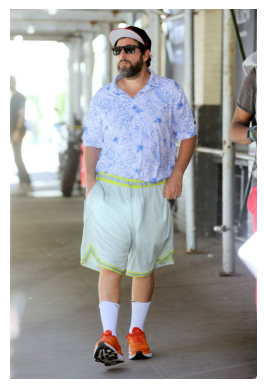

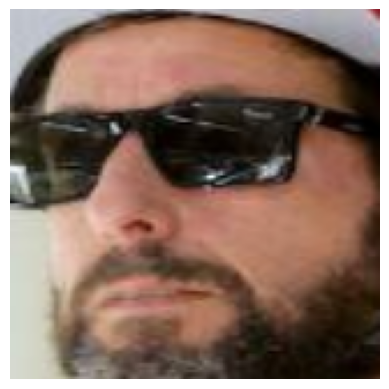

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step

Predicted Class Index: 13
Name: Adam Sandler
Confidence: 34.66%
Classes: [0.34656247 0.12160827 0.06489702 0.05457954 0.03703607 0.03703228
 0.03360169 0.02808761 0.02545143 0.01928329]


In [21]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_pil = load_img(filename)
img = np.array(img_pil).astype('uint8')

plt.imshow(img)
plt.axis('off')
plt.show()

cropped = crop_face_mtcnn(img)

if cropped is not None:
  cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped)
  plt.axis('off')
  plt.show()
else:
  print("No face detected")

if cropped is None:
  print("No face detected")
else:
  get_prediction(cropped)